# DeepDream with Keras

440742/440742 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


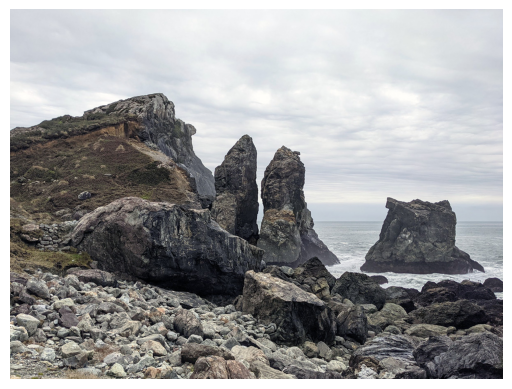

In [2]:
from tensorflow import keras
import matplotlib.pyplot as plt
base_image_path = keras.utils.get_file(
"coast.jpg", origin="https://img-datasets.s3.amazonaws.com/coast.jpg")
plt.axis("off")
plt.imshow(keras.utils.load_img(base_image_path))

## 1. Load and Display the Base Image

First, we'll load the base image that we want to apply the DeepDream effect to. We'll use `keras.utils.get_file` to download an example image and then display it.

In [3]:
from tensorflow.keras.applications import inception_v3
model = inception_v3.InceptionV3(weights="imagenet", include_top=False)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


## 2. Set up the Feature Extractor Model

DeepDream works by optimizing an image to maximally activate certain layers of a pre-trained convolutional neural network. We'll use the InceptionV3 model, pre-trained on ImageNet, as our feature extractor. We'll load it without the top (classification) layers.

In [6]:
model.summary()

Model: "inception_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, None,      │        864 │ input_layer[0][0] │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, None,      │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, None,      │      9,216 │ activation[0][0]  │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, None,      │     18,432 │ activation_1[0][… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, None,      │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, None,      │      5,120 │ max_pooling2d[0]… │
│                     │ None, 80)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ None, 80)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 80)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, None,      │    138,240 │ activation_3[0][… │
│                     │ None, 192)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ None, 192)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, None,      │          0 │ batch_normalizat

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 21,768,352 (83.04 MB)

 Non-trainable params: 34,432 (134.50 KB)

Here's a summary of the model architecture used for feature extraction:

In [4]:
layer_settings = {
"mixed4": 1.0,
"mixed5": 1.5,
"mixed6": 2.0,
"mixed7": 2.5,
}

outputs_dict = dict([
    (layer.name, layer.output)
    for layer in [model.get_layer(name)
    for name in layer_settings.keys()]]
)

feature_extractor = keras.Model(inputs=model.inputs, outputs=outputs_dict)


## 3. Define the DeepDream Loss Function

The core idea of DeepDream is to maximize the activation of specific layers in the network. We define a `compute_loss` function that calculates a weighted sum of the mean squared activations across chosen intermediate layers. The weights (`layer_settings`) determine how much each layer contributes to the total loss, influencing the complexity and scale of the generated patterns.

In [5]:
def compute_loss(input_image):
  features = feature_extractor(input_image)
  loss = tf.zeros(shape=())
  for name in features.keys():
    coeff = layer_settings[name]
    activation = features[name]
    loss += coeff * tf.reduce_mean(tf.square(activation[:, 2:-2, 2:-2, :]))
  return loss

## 4. Implement Gradient Ascent

To maximize the loss, we perform gradient ascent on the input image. This means we iteratively adjust the image's pixel values in the direction that increases the loss. We use `tf.GradientTape` to compute gradients and `tf.math.l2_normalize` to control the magnitude of the updates.

In [13]:
import tensorflow as tf

@tf.function
def gradient_ascent_step(image, learning_rate):
  with tf.GradientTape() as tape:
    tape.watch(image)
    loss = compute_loss(image)
  grads = tape.gradient(loss, image)
  grads = tf.math.l2_normalize(grads)
  image += learning_rate * grads
  return loss, image

def gradient_ascent_loop(image, iterations, learning_rate, max_loss=None):
  for i in range(iterations):
    loss, image = gradient_ascent_step(image, learning_rate)
    if max_loss is not None and loss > max_loss:
      break
    print(f"... Loss value at step {i}: {loss:.2f}")
  return image

## 5. Image Preprocessing and Deprocessing Utilities

We need helper functions to prepare the image for the InceptionV3 model (preprocessing) and to convert the generated image back into a displayable format (deprocessing).

In [14]:
step = 20
num_octave = 3
octave_scale = 1.4
iterations = 30
max_loss = 15

import numpy as np

def preprocess_image(img_path):
  img = keras.utils.load_img(img_path)
  img = keras.utils.img_to_array(img)
  img = np.expand_dims(img, axis=0)
  img = keras.applications.inception_v3.preprocess_input(img)
  return img

def deprocess_image(img):
  img = img.reshape((img.shape[1], img.shape[2], 3))
  img /= 2.0
  img += 0.5
  img *= 255
  img = np.clip(img, 0, 255).astype("uint8")
  return img

## 6. Run the DeepDream Algorithm

The DeepDream algorithm is run iteratively over multiple 'octaves' (different scales of the image). This multi-scale approach helps generate both fine and coarse details. For each octave, the image is scaled, and gradient ascent is applied. Details lost during downsampling are added back from the original image at the corresponding scale.

In [15]:
original_img = preprocess_image(base_image_path)
original_shape = original_img.shape[1:3]

successive_shapes = [original_shape]
for i in range(1, num_octave):
  shape = tuple([int(dim / (octave_scale ** i)) for dim in original_shape])
  successive_shapes.append(shape)
successive_shapes = successive_shapes[::-1]

shrunk_original_img = tf.image.resize(original_img, successive_shapes[0])

img = tf.identity(original_img)
for i, shape in enumerate(successive_shapes):
  print(f"Processing octave {i} with shape {shape}")
  img = tf.image.resize(img, shape)
  img = gradient_ascent_loop(
      img, iterations=iterations, learning_rate=step, max_loss=max_loss)
  upscaled_shrunk_original_img = tf.image.resize(shrunk_original_img, shape)
  same_size_original = tf.image.resize(original_img, shape)
  lost_detail = same_size_original - upscaled_shrunk_original_img
  img += lost_detail
  shrunk_original_img = tf.image.resize(original_img, shape)
  #keras.utils.save_img(img, f"dream_at_scale_{i}.png")
keras.utils.save_img("dream.png", deprocess_image(img.numpy()))

Processing octave 0 with shape (459, 612)
... Loss value at step 0: 0.80
... Loss value at step 1: 1.07
... Loss value at step 2: 1.44
... Loss value at step 3: 1.82
... Loss value at step 4: 2.16
... Loss value at step 5: 2.49
... Loss value at step 6: 2.86
... Loss value at step 7: 3.24
... Loss value at step 8: 3.57
... Loss value at step 9: 3.94
... Loss value at step 10: 4.27
... Loss value at step 11: 4.63
... Loss value at step 12: 4.98
... Loss value at step 13: 5.33
... Loss value at step 14: 5.68
... Loss value at step 15: 6.01
... Loss value at step 16: 6.38
... Loss value at step 17: 6.75
... Loss value at step 18: 7.06
... Loss value at step 19: 7.42
... Loss value at step 20: 7.70
... Loss value at step 21: 8.07
... Loss value at step 22: 8.38
... Loss value at step 23: 8.67
... Loss value at step 24: 8.98
... Loss value at step 25: 9.28
... Loss value at step 26: 9.56
... Loss value at step 27: 9.87
... Loss value at step 28: 10.10
... Loss value at step 29: 10.41
Proces

## 7. Display the Final DeepDream Image

After the DeepDream process is complete, the final image, which should now exhibit the psychedelic patterns, is saved and displayed.

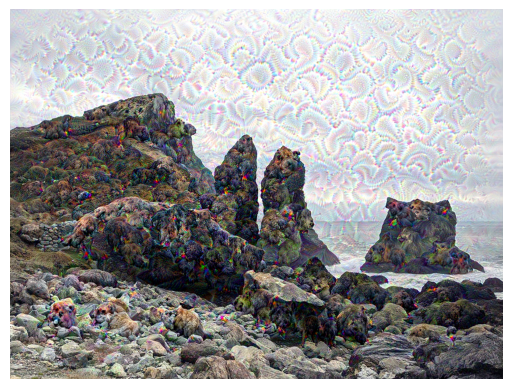

In [16]:
plt.axis("off")
plt.imshow(keras.utils.load_img("dream.png"))